### Packages Importation

In [200]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import PowerTransformer, RobustScaler, FunctionTransformer, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix


In [172]:
from sklearn import set_config
set_config(transform_output="pandas")

In [173]:
credit_data = pd.read_csv('train.csv')

/tmp/ipykernel_7396/1944128609.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  credit_data = pd.read_csv('train.csv')


### EDA & Visualization


In [174]:
cols_to_num = ["Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_of_Loan", "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]

for col in cols_to_num:
    credit_data[col] = pd.to_numeric(credit_data[col], errors='coerce')

In [175]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       95061 non-null   float64
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             93020 non-null   float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               95215 non-null   float64
 13  Type_of_Loan              88592 non-null   ob

In [176]:
credit_data.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                          4939
SSN                             0
Occupation                      0
Annual_Income                6980
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                  4785
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       9746
Changed_Credit_Limit         2091
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt             1009
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      8784
Payment_Behaviour               0
Monthly_Balance              1209
Credit_Score                    0
dtype: int64

In [177]:
credit_data.isna().sum()
credit_data.dropna(inplace=True)

In [178]:
credit_data.isna().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

In [179]:
pd.set_option('display.max_columns', None)
credit_data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Type_of_Loan'], inplace=True)
credit_data.head()

,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,23.0,Scientist,19114.12,1824.843333,3,4,3,4.0,3,7.0,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
9,28.0,Teacher,34847.84,3037.986667,2,4,6,1.0,7,1.0,7.42,2.0,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.391238,High_spent_Large_value_payments,484.591214,Good
12,28.0,Teacher,34847.84,3037.986667,2,4,6,1.0,3,1.0,6.42,2.0,Good,605.03,34.977895,26 Years and 11 Months,No,18.816215,130.115420,Low_spent_Small_value_payments,444.867032,Good
13,28.0,Teacher,34847.84,3037.986667,2,4,6,1.0,3,0.0,5.42,2.0,Good,605.03,33.381010,27 Years and 0 Months,No,18.816215,43.477190,High_spent_Large_value_payments,481.505262,Good
15,28.0,Teacher,34847.84,3037.986667,2,4,6,1.0,3,4.0,5.42,2.0,Good,605.03,32.933856,27 Years and 2 Months,No,18.816215,218.904344,Low_spent_Small_value_payments,356.078109,Good


In [180]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40147 entries, 0 to 99997
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       40147 non-null  float64
 1   Occupation                40147 non-null  object 
 2   Annual_Income             40147 non-null  float64
 3   Monthly_Inhand_Salary     40147 non-null  float64
 4   Num_Bank_Accounts         40147 non-null  int64  
 5   Num_Credit_Card           40147 non-null  int64  
 6   Interest_Rate             40147 non-null  int64  
 7   Num_of_Loan               40147 non-null  float64
 8   Delay_from_due_date       40147 non-null  int64  
 9   Num_of_Delayed_Payment    40147 non-null  float64
 10  Changed_Credit_Limit      40147 non-null  float64
 11  Num_Credit_Inquiries      40147 non-null  float64
 12  Credit_Mix                40147 non-null  object 
 13  Outstanding_Debt          40147 non-null  float64
 14  Credit_Util

In [181]:
cat_cols = credit_data.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"Unique values in {col}: {credit_data[col].unique()} \n \n")

Unique values in Occupation: ['Scientist' 'Teacher' '_______' 'Engineer' 'Entrepreneur' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Mechanic' 'Writer'
 'Accountant' 'Architect' 'Musician' 'Developer'] 
 

Unique values in Credit_Mix: ['_' 'Good' 'Standard' 'Bad'] 
 

Unique values in Credit_History_Age: ['22 Years and 1 Months' '26 Years and 8 Months' '26 Years and 11 Months'
 '27 Years and 0 Months' '27 Years and 2 Months' '17 Years and 9 Months'
 '18 Years and 1 Months' '18 Years and 2 Months' '17 Years and 3 Months'
 '17 Years and 4 Months' '17 Years and 5 Months' '17 Years and 8 Months'
 '17 Years and 10 Months' '30 Years and 7 Months' '30 Years and 8 Months'
 '30 Years and 9 Months' '30 Years and 10 Months' '30 Years and 11 Months'
 '31 Years and 2 Months' '14 Years and 8 Months' '14 Years and 10 Months'
 '15 Years and 2 Months' '21 Years and 8 Months' '21 Years and 9 Months'
 '26 Years and 6 Months' '26 Years and 7 Months' '26 Years and 9 Months'
 '19 Years and 3 M

In [182]:
credit_data.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,40147.000000,4.014700e+04,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000,40147.000000
mean,109.563081,1.822384e+05,4021.484897,17.284903,23.425686,77.539542,3.158517,21.954144,32.010287,10.718974,27.189429,1507.590173,32.208931,1444.127305,181.545440,382.515763
std,684.746468,1.486651e+06,3093.759249,117.824489,131.684544,484.886233,62.632435,15.222232,230.589089,6.887986,187.766797,1188.317395,5.062240,8396.879981,176.495313,194.877626
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.450000,0.000000,0.230000,20.881250,4.462837,0.000000,0.382558
25%,24.000000,1.884955e+04,1574.365208,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.610000,3.000000,608.160000,28.017538,41.167536,69.391772,265.060064
50%,33.000000,3.599191e+04,2987.101667,6.000000,6.000000,15.000000,3.000000,19.000000,14.000000,9.680000,6.000000,1239.810000,32.240385,78.271158,123.766491,325.458047
75%,42.000000,6.998472e+04,5717.385000,8.000000,7.000000,22.000000,5.000000,29.000000,19.000000,15.440000,9.000000,2128.870000,36.397712,169.481984,223.596171,444.782770
max,8697.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,1485.000000,67.000000,4397.000000,36.970000,2594.000000,4998.070000,49.564519,82236.000000,1572.803231,1552.946094


## Pairplot for viewing Correlation

In [ ]:
sns.pairplot(credit_data)

## Heatmap for viewing Correlation

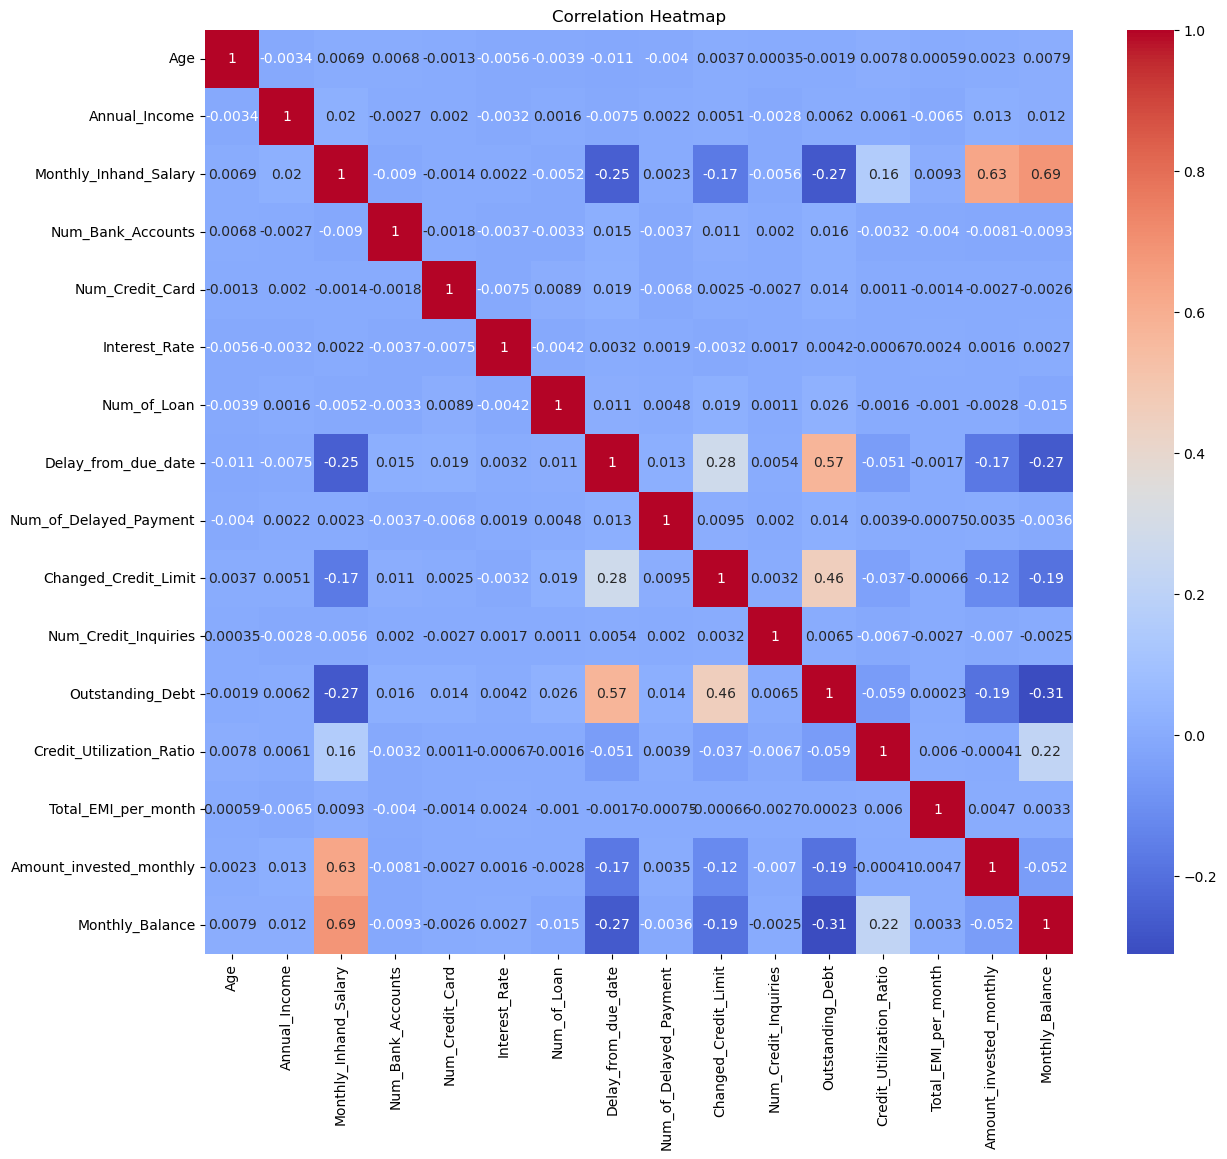

In [183]:
corr = credit_data.corr(numeric_only=True)
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [184]:
credit_data = credit_data[credit_data['Occupation'] != '_______']
credit_data = credit_data[credit_data['Credit_Mix'] != '_']
credit_data = credit_data[credit_data['Payment_Behaviour'] != '!@9#%8']


In [192]:
X = credit_data.drop('Credit_Score', axis=1)
y = credit_data['Credit_Score']
y_mapping = {
    'Poor': 0,
    'Standard': 1, 
    'Good': 2
}

y_encoded = y.map(y_mapping)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [216]:
X.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

##  Creating Custom Transformer Class


In [ ]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineering(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        ## Feature engineering      

        # Extract years and months
        X['years'] = X['Credit_History_Age'].str.extract('(\d+)\s*Years?').astype(float)
        X['months'] = X['Credit_History_Age'].str.extract('(\d+)\s*Months?').astype(float)
        
        X['age_years'] = X['years'] + X['months'] / 12
        X['total_months'] = X['years'] * 12 + X['months']
        
        X["Annual_Income_Per_Age"] = X["Annual_Income"] / X["age_years"]
        X["Has_Debt"] = (X["Outstanding_Debt"] > 0).astype(int)
        X["Debt_to_Income_Ratio"] = X["Outstanding_Debt"] / X["Annual_Income"]
        X["Loan_Per_Bank"] = X["Num_Bank_Accounts"] / (X["Num_of_Loan"] + 1)
        X["Annual_Income_Per_Loan"] = X["Annual_Income"] / (X["Num_of_Loan"] + 1)
        X["Outstanding_Debt_Per_Monthly_Balance"] = X["Outstanding_Debt"] / (X["Monthly_Balance"] + 1)
        
        return X

In [187]:
def iqr_cap(X):
    X = X.copy()
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)


class NumericalTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, skew_threshold=0.5):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):      
        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns        
        skewness = X[self.numeric_cols_].skew()

        self.high_skew_cols_ = skewness[abs(skewness) > self.skew_threshold].index.tolist()
        self.low_skew_cols_ = skewness[abs(skewness) <= self.skew_threshold].index.tolist()

        transformers = []

        if self.high_skew_cols_:
            transformers.append(
                ('high_skew',
                Pipeline([
                    ('cap', FunctionTransformer(iqr_cap, feature_names_out="one-to-one")),
                    ('power', PowerTransformer(method='yeo-johnson')),
                    ('scale', RobustScaler())
                ]),
                self.high_skew_cols_)
            )

        if self.low_skew_cols_:
            transformers.append(
                ('low_skew',
                Pipeline([
                    ('cap', FunctionTransformer(iqr_cap, feature_names_out="one-to-one")),
                    ('scale', RobustScaler())
                ]),
                self.low_skew_cols_)
            )
            
        self.column_transformer_ = ColumnTransformer(
            transformers,
            remainder='passthrough'
        )

        self.column_transformer_.fit(X)

        # Save output column names
        self.feature_names_ = self.column_transformer_.get_feature_names_out()

        return self

    def transform(self, X):
        X = pd.DataFrame(X)

        transformed = self.column_transformer_.transform(X)

        return pd.DataFrame(
            transformed,
            columns=self.feature_names_,
            index=X.index
        )

In [188]:
# class 
X.select_dtypes(include=[object]).columns

Index(['Occupation', 'Credit_Mix', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object')

In [210]:
model_pipeline = Pipeline(
    [
        ("feature_extraction", FeatureEngineering()),
        (
            "col_preprocessing",
            ColumnTransformer(
                transformers=[
                    (
                        "num_cols",
                        NumericalTransformer(),
                        make_column_selector(dtype_include=np.number),
                    ),
                    (
                        "occupation_encode",
                        OrdinalEncoder(
                            categories=[
                                [
                                    "Doctor",
                                    "Lawyer",
                                    "Engineer",
                                    "Developer",
                                    "Scientist",
                                    "Architect",
                                    "Accountant",
                                    "Manager",
                                    "Media_Manager",
                                    "Entrepreneur",
                                    "Mechanic",
                                    "Teacher",
                                    "Journalist",
                                    "Writer",
                                    "Musician",
                                ]
                            ],
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ["Occupation"],
                    ),
                    (
                        "payment_behaviour_encode",
                        OrdinalEncoder(
                            categories=[
                                [
                                    "High_spent_Large_value_payments",
                                    "High_spent_Medium_value_payments",
                                    "High_spent_Small_value_payments",
                                    "Low_spent_Large_value_payments",
                                    "Low_spent_Medium_value_payments",
                                    "Low_spent_Small_value_payments",
                                ]
                            ],
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ["Payment_Behaviour"],
                    ),
                    (
                        "credit_encode",
                        OrdinalEncoder(
                            categories=[["Bad", "Good", "Standard"]],
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ["Credit_Mix"],
                    ),
                    (
                        "payment_min_encode",
                        OrdinalEncoder(
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                        ["Payment_of_Min_Amount"],
                    ),                    
                    ("drop_objects", "drop", X.select_dtypes(include=[object]).columns),
                ],
                remainder="passthrough",
            ),
        ),
        ("smote", SMOTE(random_state=42)),
        ("classifier", DummyClassifier()),
    ]
)


param_grid = [
    # Random Forest
    {
        "classifier": [RandomForestClassifier()],
        "classifier__n_estimators": [100, 200],
        # "classifier__max_depth": [5, 10, None],
        "classifier__max_features": ["sqrt", "log2"],
    },
    # Gradient Boosting
    {
        "classifier": [GradientBoostingClassifier()],
        "classifier__n_estimators": [50, 100, 200, 300],
        "classifier__learning_rate": [0.01, 0.1, 1],
        "classifier__max_depth": [3, 5],
        # "classifier__subsample": [0.6, 0.8, 1.0],
    },
    # XGBoost
    {
        "classifier": [XGBClassifier()],
        "classifier__n_estimators": [50, 100, 200, 300],
        "classifier__learning_rate": [0.01, 0.1, 1],
        "classifier__max_depth": [3, 5],
        # "classifier__subsample": [0.6, 0.8, 1.0],
        # "classifier__colsample_bytree": [0.6, 0.8, 1.0],
    },
]

SyntaxError: invalid character '🔥' (U+1F525) (1938541891.py, line 94)

In [211]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

In [212]:
X.columns

Index(['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary',
       'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [213]:

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(estimator=Pipeline(steps=[('feature_extraction',
                                        FeatureEngineering()),
                                       ('col_preprocessing',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num_cols',
                                                                         NumericalTransformer(),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x74af47686510>),
                                                                        ('occupation_encode',
                                                                         OrdinalEncoder(categories=[['Doctor',
                                                                                                     'Lawyer',
                                                                                                     'Engin...
                                                                         ['Payment_of_Min_Amount']),
                                                                        ('drop_objects',
                                                                         'drop',
                                                                         Index(['Occupation', 'Credit_Mix', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Payment_Behaviour'],
      dtype='object'))])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('classifier', DummyClassifier())]),
             n_jobs=-1,
             param_grid=[{'classifier': [RandomForestClassifier()],
                          'classifier__n_estimators': [100, 200]}],
             scoring='f1_macro', verbose=1)

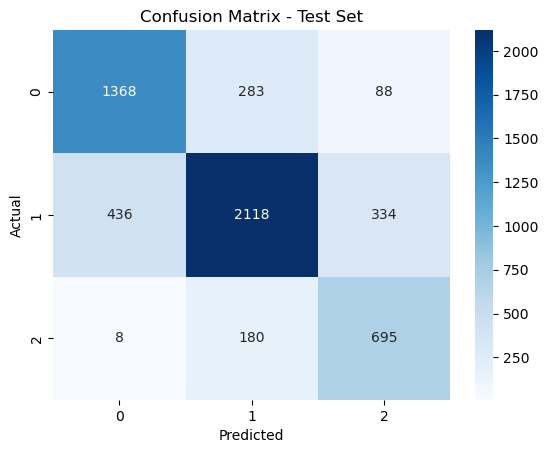

array([[1368,  283,   88],
       [ 436, 2118,  334],
       [   8,  180,  695]])

In [214]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()
cm

In [215]:
t = classification_report(y_test, y_pred)
print(t)

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1739
           1       0.82      0.73      0.77      2888
           2       0.62      0.79      0.69       883

    accuracy                           0.76      5510
   macro avg       0.73      0.77      0.75      5510
weighted avg       0.77      0.76      0.76      5510



In [ ]:
# https://www.kaggle.com/datasets/junaid512/credit-scoring-dataset-creditworthiness-prediction